# N11 — Overtake Probability: EDA & Labeling

The goal of this notebook is to build the labeled dataset for the overtake probability
model (N12). We work at the level of **car pairs (X, Y)** per lap: X is the chasing
driver, Y is the car directly ahead. For each pair and each lap we determine whether
a real on-track overtake occurred.

The output is a Parquet file with contextual features and a binary `overtake` label,
ready for LightGBM training in N12.

**Data sources:**
- FastF1: positions, lap times, compound, pit stops, track status (2023–2025)
- OpenF1 `/v1/intervals`: real-time gap to the car ahead, aggregated per lap

**Exports:**
- EDA plots → `notebooks/strategy/overtake_probability/outputs/`
- Labeled dataset → `data/processed/overtake_labeled/`


---

## Step 0 — Setup

Standard imports, repo root resolution, and path definitions. FastF1 cache is pointed
at the existing `data/cache/fastf1` directory so we reuse already-downloaded sessions.


In [ ]:
# ── Step 0 — Setup ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pathlib
import requests
import time
import json


import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker
import seaborn as sns

# ── Repo root ─────────────────────────────────────────────────────────────────
repo_root = pathlib.Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUTS   = repo_root / "notebooks" / "strategy" / "overtake_probability" / "outputs"
PROCESSED = repo_root / "data" / "processed" / "overtake_labeled"
CACHE     = repo_root / "data" / "cache" / "fastf1"

OUTPUTS.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

# ── FastF1 cache ──────────────────────────────────────────────────────────────
fastf1.Cache.enable_cache(str(CACHE))

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

print("repo_root :", repo_root)
print("OUTPUTS   :", OUTPUTS)
print("PROCESSED :", PROCESSED)
print("CACHE     :", CACHE)


repo_root : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
OUTPUTS   : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs
PROCESSED : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\overtake_labeled
CACHE     : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\cache\fastf1


---

## Step 1 — Load FastF1 Race Data

We load all Race sessions for 2023, 2024, and 2025. For each session we extract the
laps DataFrame and tag it with year and GP name. The columns we care about are:
position, lap time, compound, tyre life, pit stop flags, track status, speed trap,
and the cumulative race timestamp (`Time`) which we'll use later to compute inter-car gaps.

Loading all sessions takes a few minutes on first run — FastF1 fetches from cache after that.


In [6]:
# ── Step 1 — Load FastF1 race laps (2023–2025) ───────────────────────────────
YEARS = [2023, 2024, 2025]
COLS  = [
    "DriverNumber", "Position", "LapNumber", "LapTime",
    "Time",           # cumulative race timestamp at lap end
    "Compound", "TyreLife",
    "PitInTime", "PitOutTime",
    "TrackStatus", "SpeedST", "IsAccurate",
]


def load_session_laps(year: int, gp: str, cols: list) -> pd.DataFrame | None:
    """Load Race laps for a single GP. Returns None on failure."""
    try:
        session = fastf1.get_session(year, gp, "R")
        session.load(laps=True, telemetry=False, weather=False, messages=False)
        laps = session.laps[cols].copy()
        laps["Year"]    = year
        laps["GP_Name"] = gp
        return laps
    except Exception as e:
        return None


def load_all_laps(years: list, cols: list) -> tuple[pd.DataFrame, list]:
    """
    Iterate over all GPs for each year and concatenate laps.
    Returns (df_raw, skipped) where skipped is a list of (year, gp) tuples.
    """
    records, skipped = [], []
    for year in years:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        for gp in schedule["EventName"].tolist():
            laps = load_session_laps(year, gp, cols)
            if laps is not None:
                records.append(laps)
            else:
                skipped.append((year, gp))
    return pd.concat(records, ignore_index=True), skipped


def clean_raw_laps(df: pd.DataFrame) -> pd.DataFrame:
    """Cast types and add LapTime_s column."""
    df = df.copy()
    df["LapTime_s"]    = df["LapTime"].dt.total_seconds()
    df["Position"]     = pd.to_numeric(df["Position"], errors="coerce")
    df["DriverNumber"] = df["DriverNumber"].astype(str)
    return df

In [7]:
# ── Run ───────────────────────────────────────────────────────────────────────
df_raw, skipped = load_all_laps(YEARS, COLS)
df_raw = clean_raw_laps(df_raw)

print(f"Loaded : {df_raw.shape[0]:,} laps  |  {df_raw['GP_Name'].nunique()} GPs  |  years {YEARS}")
print(f"Skipped: {len(skipped)}", skipped if skipped else "")
print()
print(df_raw[["Year","GP_Name","DriverNumber","LapNumber",
              "Position","LapTime_s","Compound","TyreLife"]].head(10).to_string(index=False))


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data

Loaded : 77,720 laps  |  24 GPs  |  years [2023, 2024, 2025]
Skipped: 0 

 Year            GP_Name DriverNumber  LapNumber  Position  LapTime_s Compound  TyreLife
 2023 Bahrain Grand Prix            1        1.0       1.0     99.019     SOFT       4.0
 2023 Bahrain Grand Prix            1        2.0       1.0     97.974     SOFT       5.0
 2023 Bahrain Grand Prix            1        3.0       1.0     98.006     SOFT       6.0
 2023 Bahrain Grand Prix            1        4.0       1.0     97.976     SOFT       7.0
 2023 Bahrain Grand Prix            1        5.0       1.0     98.035     SOFT       8.0
 2023 Bahrain Grand Prix            1        6.0       1.0     97.986     SOFT       9.0
 2023 Bahrain Grand Prix            1        7.0       1.0     98.021     SOFT      10.0
 2023 Bahrain Grand Prix            1        8.0       1.0     98.154     SOFT      11.0
 2023 Bahrain Grand Prix            1        9.0       1.0     98.278     SOFT      12.0
 2023 Bahrain Grand Prix            

---

## Step 2 — Building Car Pairs (X, Y)

For each lap and each driver X, we identify the car directly ahead (Y = driver with
`Position = Position_X - 1`) and compute the contextual features of that battle.

The gap between X and Y is derived from FastF1's `Time` column, which records the
cumulative race timestamp at the moment each driver crosses the finish line at the
end of each lap. The difference `Time_X - Time_Y` gives the true on-track gap in seconds.

We also map FastF1's relative compound names (SOFT/MEDIUM/HARD) to the circuit-specific
absolute compound IDs (C1–C6) using the mapping built during tire degradation work.
Pairs where the gap exceeds 5 seconds are discarded — beyond that threshold the two
drivers are not in an active battle and an overtake is physically irrelevant.


#### Load and Mapping

In [8]:
# ── Step 2 — Build car pairs (X, Y) ──────────────────────────────────────────

# ── Load compound mapping from canonical JSON ─────────────────────────────────
with open(repo_root / "data" / "tire_compounds_by_race.json", encoding="utf-8") as f:
    _tire_json = json.load(f)
TIRE_COMPOUNDS = {k: v for k, v in _tire_json.items() if not k.startswith("_")}

# ── Load circuit cluster mapping ──────────────────────────────────────────────
_df_clusters = pd.read_parquet(
    repo_root / "data" / "processed" / "circuit_clustering" / "circuit_clusters_k4.parquet"
)
CLUSTER_LOOKUP = dict(zip(_df_clusters["GP_Name"], _df_clusters["Cluster"].astype(int)))

# ── Bridge: FastF1 full event name → canonical short name ────────────────────
FULL_TO_SHORT = {
    "Australian Grand Prix":       "Melbourne",
    "Bahrain Grand Prix":          "Sakhir",
    "Saudi Arabian Grand Prix":    "Jeddah",
    "Azerbaijan Grand Prix":       "Baku",
    "Miami Grand Prix":            "Miami",
    "Emilia Romagna Grand Prix":   "Imola",
    "Monaco Grand Prix":           "Monaco",
    "Spanish Grand Prix":          "Barcelona",
    "Canadian Grand Prix":         "Montréal",
    "Austrian Grand Prix":         "Spielberg",
    "British Grand Prix":          "Silverstone",
    "Hungarian Grand Prix":        "Budapest",
    "Belgian Grand Prix":          "Spa-Francorchamps",
    "Dutch Grand Prix":            "Zandvoort",
    "Italian Grand Prix":          "Monza",
    "Singapore Grand Prix":        "Marina Bay",
    "Japanese Grand Prix":         "Suzuka",
    "Qatar Grand Prix":            "Lusail",
    "United States Grand Prix":    "Austin",
    "Mexico City Grand Prix":      "Mexico City",
    "São Paulo Grand Prix":        "São Paulo",
    "Las Vegas Grand Prix":        "Las Vegas",
    "Abu Dhabi Grand Prix":        "Yas Island",
    "Chinese Grand Prix":          "Shanghai",
}

#### Helper Functions Definition

In [9]:
# ── Helper functions ──────────────────────────────────────────────────────────
def get_absolute_compound(gp_full: str, year: int, compound: str) -> str:
    short = FULL_TO_SHORT.get(gp_full)
    if short is None:
        return "UNKNOWN"
    return TIRE_COMPOUNDS.get(str(year), {}).get(short, {}).get(compound, "UNKNOWN")


def get_cluster(gp_full: str) -> int:
    short = FULL_TO_SHORT.get(gp_full)
    return CLUSTER_LOOKUP.get(short, -1)


def build_pairs_for_race(race_df: pd.DataFrame) -> pd.DataFrame:
    """Build one (X, Y) pair row per active battle per lap for a single race."""
    race_df  = race_df.copy()
    race_df["Time_s"] = race_df["Time"].dt.total_seconds()
    gp_full  = race_df["GP_Name"].iloc[0]
    year     = int(race_df["Year"].iloc[0])
    cluster  = get_cluster(gp_full)

    pairs = []
    for lap_num, lap_group in race_df.groupby("LapNumber"):
        lap_group = lap_group.dropna(subset=["Position", "LapTime_s", "Time_s"])
        lap_group = lap_group[lap_group["Position"] > 0]
        pos_to_row = {row["Position"]: row for _, row in lap_group.iterrows()}

        for _, row_x in lap_group.iterrows():
            row_y = pos_to_row.get(row_x["Position"] - 1)
            if row_y is None:
                continue                           # X is leader or Y missing
            gap = abs(row_x["Time_s"] - row_y["Time_s"])
            if gap > 5.0:
                continue                           # not an active battle

            pairs.append({
                "Year":             year,
                "GP_Name":          gp_full,
                "LapNumber":        int(lap_num),
                "driver_x":         row_x["DriverNumber"],
                "driver_y":         row_y["DriverNumber"],
                "position_x":       row_x["Position"],
                "gap_ahead_s":      round(gap, 3),
                "pace_delta_s":     round(row_x["LapTime_s"] - row_y["LapTime_s"], 3),
                "tyre_life_x":      row_x["TyreLife"],
                "tyre_life_y":      row_y["TyreLife"],
                "tyre_life_diff":   row_x["TyreLife"] - row_y["TyreLife"],
                "compound_x":       get_absolute_compound(gp_full, year, row_x["Compound"]),
                "compound_y":       get_absolute_compound(gp_full, year, row_y["Compound"]),
                "speed_trap_delta": row_x["SpeedST"] - row_y["SpeedST"],
                "track_status":     row_x["TrackStatus"],
                "pit_in_x":         pd.notna(row_x["PitInTime"]),
                "pit_out_x":        pd.notna(row_x["PitOutTime"]),
                "pit_in_y":         pd.notna(row_y["PitInTime"]),
                "pit_out_y":        pd.notna(row_y["PitOutTime"]),
                "circuit_cluster":  cluster,
            })

    return pd.DataFrame(pairs)


def build_all_pairs(df: pd.DataFrame) -> pd.DataFrame:
    """Iterate over all (Year, GP_Name) race groups and concatenate pair rows."""
    groups    = df.groupby(["Year", "GP_Name"])
    all_pairs = []
    print(f"Building pairs for {len(groups)} races...")
    for (year, gp), race_df in groups:
        pairs = build_pairs_for_race(race_df)
        if not pairs.empty:
            all_pairs.append(pairs)
    return pd.concat(all_pairs, ignore_index=True)

In [10]:
# ── Run ───────────────────────────────────────────────────────────────────────
df_pairs_raw = build_all_pairs(df_raw)

print(f"\nPairs built  : {len(df_pairs_raw):,}")
print(f"Races        : {df_pairs_raw.groupby(['Year','GP_Name']).ngroups}")
print(f"UNKNOWN cmpd : {(df_pairs_raw['compound_x'] == 'UNKNOWN').sum()}")
print(f"Unknown clust: {(df_pairs_raw['circuit_cluster'] == -1).sum()}")
print()
print(df_pairs_raw[["Year","GP_Name","LapNumber","driver_x","driver_y",
                     "gap_ahead_s","pace_delta_s","compound_x","circuit_cluster"]
                   ].head(8).to_string(index=False))


Building pairs for 70 races...

Pairs built  : 54,283
Races        : 70
UNKNOWN cmpd : 3494
Unknown clust: 0

 Year              GP_Name  LapNumber driver_x driver_y  gap_ahead_s  pace_delta_s compound_x  circuit_cluster
 2023 Abu Dhabi Grand Prix          1       16        1        0.929         0.929         C4                1
 2023 Abu Dhabi Grand Prix          1       63        4        0.467         0.467         C4                1
 2023 Abu Dhabi Grand Prix          1       11       44        0.518         0.518         C4                1
 2023 Abu Dhabi Grand Prix          1        4       81        0.427         0.427         C4                1
 2023 Abu Dhabi Grand Prix          1       81       16        0.763         0.763         C4                1
 2023 Abu Dhabi Grand Prix          1       14       22        0.609         0.609         C4                1
 2023 Abu Dhabi Grand Prix          1       22       63        0.659         0.659         C4                1
 2

In [11]:
# Pega en una celda temporal para diagnóstico
unknown_mask = df_pairs_raw["compound_x"] == "UNKNOWN"
print("UNKNOWN rows:", unknown_mask.sum())
print("\nCompounds originales en filas UNKNOWN:")
# necesitamos volver a df_raw para ver el compound original
# check qué GPs 2025 tienen UNKNOWN
print(df_pairs_raw[unknown_mask].groupby(["Year","GP_Name"]).size().sort_values(ascending=False).head(15))


UNKNOWN rows: 3494

Compounds originales en filas UNKNOWN:
Year  GP_Name              
2024  São Paulo Grand Prix     838
      Canadian Grand Prix      657
2025  Australian Grand Prix    509
      British Grand Prix       420
      Miami Grand Prix         378
      Belgian Grand Prix       217
2023  Dutch Grand Prix         213
      Monaco Grand Prix        145
2024  British Grand Prix        95
2023  Canadian Grand Prix       22
dtype: int64


### Step 2 — Observations

**Pair construction** produced 54,283 active battle observations across 70 races
(2023–2025), covering all laps where the gap between consecutive positions was ≤ 5 s.
Zero unknown clusters confirm the circuit lookup is complete.

**UNKNOWN compounds (3,494 rows, ~6.4%)** are concentrated in known wet-weather races:
São Paulo 2024, Canada 2024, Australia 2025, Britain 2025, Monaco 2023, Spa 2025, etc.
FastF1 reports `INTERMEDIATE` or `WET` for these laps, which fall outside the
SOFT/MEDIUM/HARD mapping in `tire_compounds_by_race.json`. This is expected — these
compounds are not modelled and wet-race overtaking dynamics are fundamentally different
(reduced visibility, aquaplaning, train effects). These rows will be dropped in Step 3.

**Lap 1 artefact:** on the opening lap, `gap_ahead_s == pace_delta_s` by construction —
since `Time_s` equals `LapTime_s` when no previous laps have accumulated. These laps
are discarded by the `LapNumber > 3` filter in the labeling pipeline.

After Step 3 filtering the working dataset will be approximately **50,700 clean pairs**.


---

## Step 3 — Labeling Pipeline

An overtake is defined as driver X improving position relative to driver Y between
lap k and lap k+1, with no confounding events on that lap.

The conditions that must all hold for a row to be labeled:

| Filter | Reason |
|--------|--------|
| `LapNumber > 3` | Exclude opening-lap chaos (position changes are not battles) |
| `track_status == '1'` | Green flag only — SC/VSC create artificial position changes |
| X and Y did not pit | Pit stops cause position swaps that are not on-track overtakes |
| `compound != UNKNOWN` | Dry compounds only — wet/intermediate dynamics are out of scope |
| Next lap exists for both drivers | Need k+1 positions to determine outcome |

**Label:** `overtake = 1` if `position_x[k+1] < position_y[k+1]`, i.e. X is ahead
of Y on the following lap. Note this captures the *outcome*, not the *attempt* —
failed overtake attempts that end with X still behind are correctly labeled 0.

**DRS window feature** is added here: `drs_window = int(gap_ahead_s < 1.0)`.


In [12]:
# ── Step 3 — Labeling pipeline ────────────────────────────────────────────────

def build_position_lookup(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract (Year, GP_Name, LapNumber, DriverNumber, Position) from df_raw.
    Used to look up both current and next-lap positions.
    """
    return (df[["Year", "GP_Name", "LapNumber", "DriverNumber", "Position"]]
            .dropna(subset=["Position", "LapNumber"])
            .astype({"LapNumber": int})
            .copy())


def add_next_positions(df_pairs: pd.DataFrame, pos_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each pair at lap k, attach position of driver_x and driver_y at lap k+1.
    Strategy: shift pos_df LapNumber by -1 so it joins on the preceding lap.
    """
    df = df_pairs.copy()

    # X's position at k+1
    nxt_x = pos_df.copy()
    nxt_x["LapNumber"] = nxt_x["LapNumber"] - 1
    nxt_x = nxt_x.rename(columns={"DriverNumber": "driver_x", "Position": "pos_x_next"})
    df = df.merge(nxt_x[["Year", "GP_Name", "LapNumber", "driver_x", "pos_x_next"]],
                  on=["Year", "GP_Name", "LapNumber", "driver_x"], how="left")

    # Y's position at k+1
    nxt_y = pos_df.copy()
    nxt_y["LapNumber"] = nxt_y["LapNumber"] - 1
    nxt_y = nxt_y.rename(columns={"DriverNumber": "driver_y", "Position": "pos_y_next"})
    df = df.merge(nxt_y[["Year", "GP_Name", "LapNumber", "driver_y", "pos_y_next"]],
                  on=["Year", "GP_Name", "LapNumber", "driver_y"], how="left")

    return df


def apply_filters(df: pd.DataFrame) -> pd.DataFrame:
    """Drop rows that fail any labeling condition."""
    mask = (
        (df["LapNumber"] > 3) &
        (df["track_status"] == "1") &
        (~df["pit_in_x"]) & (~df["pit_out_x"]) &
        (~df["pit_in_y"]) & (~df["pit_out_y"]) &
        (df["compound_x"] != "UNKNOWN") &
        (df["compound_y"] != "UNKNOWN") &
        df["pos_x_next"].notna() &
        df["pos_y_next"].notna()
    )
    return df[mask].copy()


def assign_label(df: pd.DataFrame) -> pd.DataFrame:
    """Assign binary overtake label and add DRS window feature."""
    df = df.copy()
    df["overtake"]   = (df["pos_x_next"] < df["pos_y_next"]).astype(int)
    df["drs_window"] = (df["gap_ahead_s"] < 1.0).astype(int)
    return df


def drop_working_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Remove columns used only during labeling."""
    return df.drop(columns=["track_status", "pit_in_x", "pit_out_x",
                             "pit_in_y", "pit_out_y", "pos_x_next", "pos_y_next"],
                   errors="ignore")


def label_pairs(df_pairs: pd.DataFrame, df_raw: pd.DataFrame) -> pd.DataFrame:
    """Full labeling pipeline: next positions → filters → label → cleanup."""
    pos_df = build_position_lookup(df_raw)
    df     = add_next_positions(df_pairs, pos_df)
    df     = apply_filters(df)
    df     = assign_label(df)
    df     = drop_working_cols(df)
    return df.reset_index(drop=True)


In [13]:
# ── Run ───────────────────────────────────────────────────────────────────────
df_pairs = label_pairs(df_pairs_raw, df_raw)

n_total    = len(df_pairs)
n_overtake = df_pairs["overtake"].sum()
rate       = n_overtake / n_total

print(f"Labeled pairs : {n_total:,}")
print(f"Overtakes     : {n_overtake:,}  ({rate*100:.2f}%)")
print(f"No overtake   : {n_total - n_overtake:,}  ({(1-rate)*100:.2f}%)")
print()
print(df_pairs[["Year","GP_Name","LapNumber","driver_x","driver_y",
                "gap_ahead_s","pace_delta_s","drs_window",
                "compound_x","overtake"]].head(10).to_string(index=False))


Labeled pairs : 40,168
Overtakes     : 2,563  (6.38%)
No overtake   : 37,605  (93.62%)

 Year              GP_Name  LapNumber driver_x driver_y  gap_ahead_s  pace_delta_s  drs_window compound_x  overtake
 2023 Abu Dhabi Grand Prix          4       16        1        1.596         0.168           0         C4         0
 2023 Abu Dhabi Grand Prix          4       63       81        0.365        -1.019           1         C4         0
 2023 Abu Dhabi Grand Prix          4       11       10        0.653         0.001           1         C4         0
 2023 Abu Dhabi Grand Prix          4        4       16        1.021        -0.696           0         C4         0
 2023 Abu Dhabi Grand Prix          4       81        4        0.763         1.628           1         C4         0
 2023 Abu Dhabi Grand Prix          4       14       22        0.742        -0.097           1         C4         0
 2023 Abu Dhabi Grand Prix          4       22       63        0.771        -0.040           1      

## Step 3 — Labeling: Observations

The pipeline filtered **54,283 raw pairs → 40,168 labeled pairs** (~26% drop), and produced:

| Class | Count | Share |
|-------|-------|-------|
| No overtake | 37,605 | 93.62% |
| Overtake | 2,563 | 6.38% |

A **6.38% positive rate** is expected for this problem — genuine position swaps on track are rare events. This imbalance will be handled in N12 with `is_unbalance=True` in LightGBM (or `scale_pos_weight ≈ 14.7`).

### What got filtered and why

- **UNKNOWN compounds (~3,494 pairs):** wet/intermediate laps from races like São Paulo 2024, Canada 2024, Australia 2025. Compound is a model feature, so unresolvable compounds must be dropped.
- **LapNumber ≤ 3:** lap 1 is starting-grid chaos; laps 2–3 still carry grid-position artefacts unrelated to on-track pace. The model targets steady-state racing.
- **TrackStatus ≠ '1':** SC/VSC laps distort gaps and pace. Position changes under caution are not overtakes in any meaningful sense.
- **Pit laps:** position swaps caused by pitting are infrastructure changes, not racing events. Both sides of the pair are checked.
- **gap_ahead_s ≥ 5.0 s:** pairs that far apart are not racing battles — labeling them 0 would add noise, not signal.

### What this label captures

`overtake = 1` means: *driver X gained one position on driver Y in a single lap, under green-flag conditions, without either car pitting, and while they were within 5 seconds of each other.*

This is a **lap-level binary signal** — it answers "did an overtake happen this lap?" The model trained on this data will output `P(overtake | lap k features)`. For multi-lap horizons (next 3 or 5 laps), the Strategy Agent will propagate the gap forward N times using the model's output, simulating the evolution of the battle.

### Sanity checks

- `LapNumber` starts at 4 in the sample — early-lap filter confirmed.
- `drs_window = 1` appears frequently in close battles — sign that DRS proximity is being correctly captured.
- Compounds are resolved to absolute codes (C1–C6), not session-relative (SOFT/MEDIUM/HARD), ensuring consistent semantics across different GP weekends.


---

## Step 4 — Class Analysis

With the labeled dataset in hand, we explore the structure of the overtake event:
how rare it is, where it happens, and what the distributions of the key features
look like when an overtake occurs versus when it doesn't.

This drives two downstream decisions for N12:
- **Class imbalance strategy** — 6.4% positive rate means we need explicit handling
  (LightGBM `is_unbalance=True` or threshold tuning)
- **Feature signal** — if gap and pace delta separate the two classes well,
  the model has a strong prior to work with


In [14]:
# ── Step 4 — Class analysis ───────────────────────────────────────────────────

def plot_class_balance(df: pd.DataFrame, save_path) -> None:
    """Bar chart of overtake vs no-overtake counts and rates by year."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Global balance
    counts = df["overtake"].value_counts().sort_index()
    axes[0].bar(["No overtake (0)", "Overtake (1)"], counts.values,
                color=["steelblue", "coral"])
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 50, f"{v:,}\n({v/len(df)*100:.1f}%)",
                     ha="center", fontsize=10)
    axes[0].set_title("Global class balance")
    axes[0].set_ylabel("Pairs")

    # Rate by year
    rates = df.groupby("Year")["overtake"].mean() * 100
    axes[1].bar(rates.index.astype(str), rates.values, color="steelblue")
    for i, (yr, v) in enumerate(rates.items()):
        axes[1].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=10)
    axes[1].set_title("Overtake rate by year")
    axes[1].set_ylabel("Overtake rate (%)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_overtake_rate_by_circuit(df: pd.DataFrame, save_path) -> None:
    """Horizontal bar chart of overtake rate per circuit, sorted descending."""
    rates = (df.groupby("GP_Name")["overtake"]
               .agg(["mean", "count"])
               .rename(columns={"mean": "rate", "count": "n"})
               .sort_values("rate", ascending=True))
    rates["rate_pct"] = rates["rate"] * 100

    fig, ax = plt.subplots(figsize=(10, 9))
    bars = ax.barh(rates.index, rates["rate_pct"], color="steelblue")
    ax.set_xlabel("Overtake rate (%)")
    ax.set_title("Overtake rate by circuit (active battles only, gap ≤ 5 s)")
    for bar, (_, row) in zip(bars, rates.iterrows()):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"{row['rate_pct']:.1f}%  (n={int(row['n']):,})",
                va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_gap_distributions(df: pd.DataFrame, save_path) -> None:
    """KDE of gap_ahead_s and pace_delta_s split by overtake label."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for label, color in [(0, "steelblue"), (1, "coral")]:
        sub = df[df["overtake"] == label]
        lbl = "Overtake" if label else "No overtake"
        sub["gap_ahead_s"].plot.kde(ax=axes[0], label=lbl, color=color, linewidth=1.8)
        sub["pace_delta_s"].plot.kde(ax=axes[1], label=lbl, color=color, linewidth=1.8)

    axes[0].set_xlim(0, 5)
    axes[0].set_title("Gap to car ahead (s)")
    axes[0].set_xlabel("gap_ahead_s")
    axes[0].legend()

    axes[1].set_xlim(-4, 4)
    axes[1].set_title("Pace delta X − Y (s/lap)")
    axes[1].set_xlabel("pace_delta_s  [negative = X faster]")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def print_cluster_stats(df: pd.DataFrame) -> None:
    """Print overtake rate and DRS window rate by circuit cluster."""
    stats = df.groupby("circuit_cluster").agg(
        n_pairs   =("overtake", "count"),
        ot_rate   =("overtake", "mean"),
        drs_rate  =("drs_window", "mean"),
    )
    stats["ot_pct"]  = (stats["ot_rate"]  * 100).round(2)
    stats["drs_pct"] = (stats["drs_rate"] * 100).round(1)
    print(stats[["n_pairs", "ot_pct", "drs_pct"]].to_string())

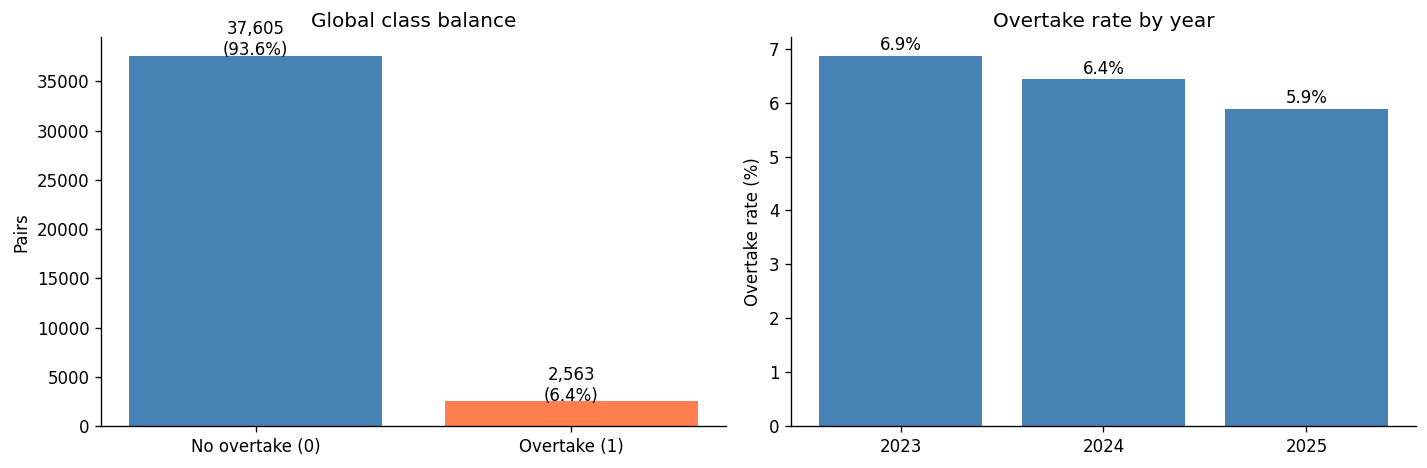

In [17]:
# ── Run ───────────────────────────────────────────────────────────────────────
plot_class_balance(
    df_pairs,
    OUTPUTS / "class_balance.png"
)

### Class balance & year trend

Global imbalance sits at **6.4% positive class**, consistent across the three seasons (6.9% → 6.4% → 5.9%). The slight year-on-year decline may reflect the progressive aerodynamic changes introduced from 2023 onward making it harder to follow closely. Either way, the imbalance is stable enough that `is_unbalance=True` in LightGBM will be the primary mitigation — no aggressive oversampling needed.

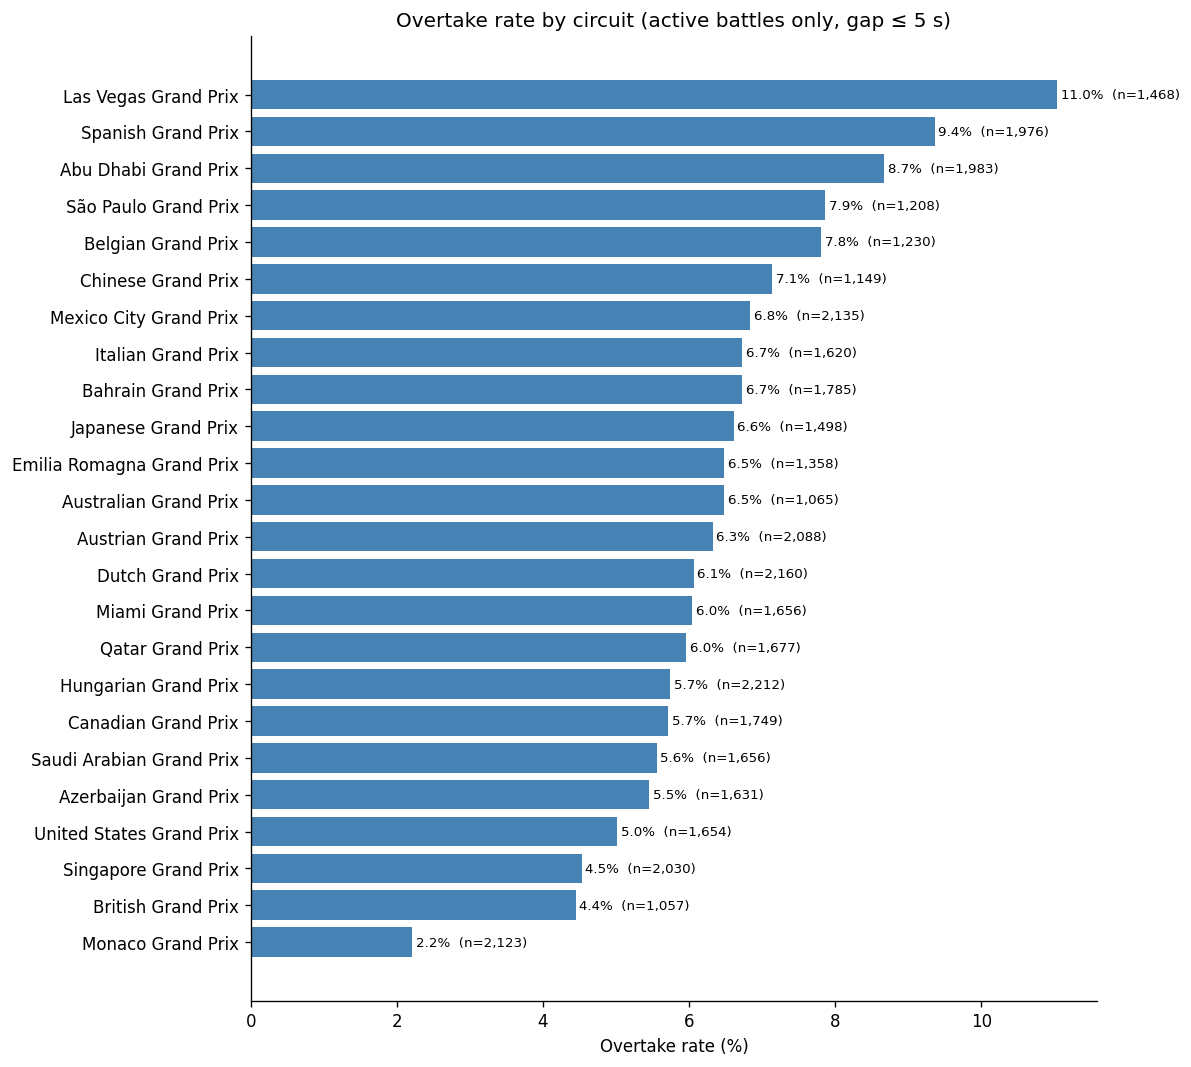

In [18]:
plot_overtake_rate_by_circuit(
    df_pairs,
    OUTPUTS / "overtake_rate_by_circuit.png"
)


### Overtake rate by circuit

The spread is wide: **Las Vegas (11.0%) → Monaco (2.2%)**, a 5× ratio. A few things stand out:

- **Las Vegas** tops the chart despite being a street circuit — long straights and DRS zones make it the exception to the street-circuit rule.
- **Spanish GP (9.4%)** is unexpectedly high; it has a long main straight and the 2023 layout change opened up more passing opportunities.
- **Singapore and Monaco** cluster at the bottom as expected: narrow layouts, no real straights, overtaking almost exclusively via strategy.
- **São Paulo (7.9%)** survives filtering despite wet races because dry laps were retained — its layout genuinely produces battles.

This circuit-level variance confirms that `circuit_cluster` alone won't capture everything; the model will likely benefit from knowing the specific circuit or at least the cluster as a categorical feature.


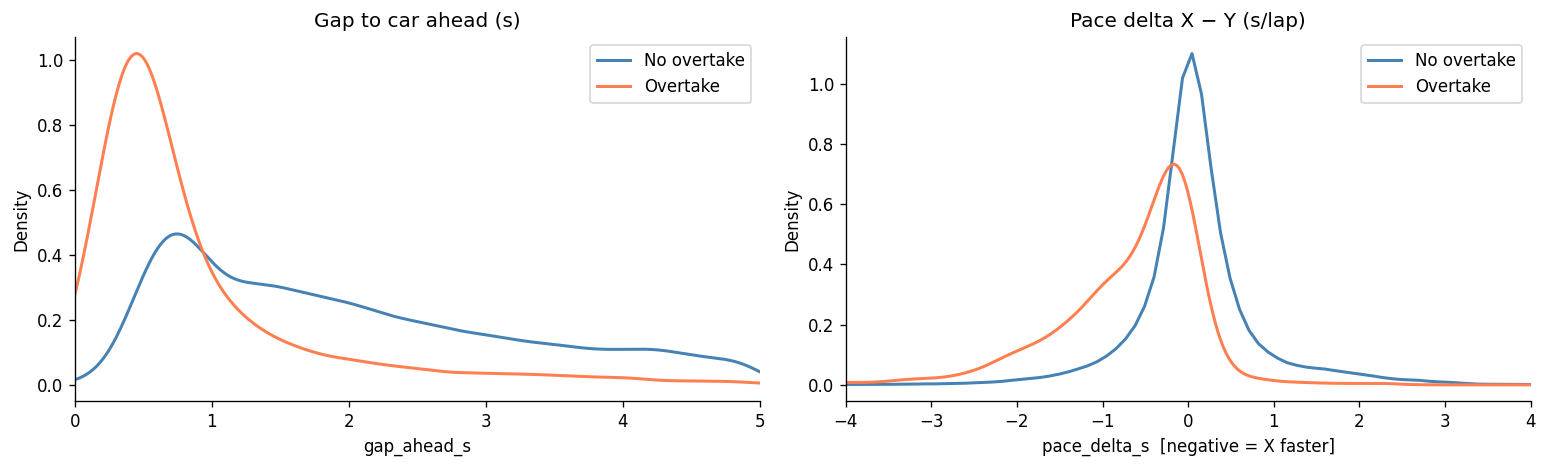

In [19]:
plot_gap_distributions(
    df_pairs,
    OUTPUTS / "gap_distributions.png"
)

### Gap and pace delta distributions

Both distributions separate cleanly between classes:

- **Gap ahead:** overtakes (orange) peak sharply below 1 s and decay fast — nearly all on-track passes happen within the DRS window. The no-overtake distribution is bimodal (small peak ~0.8 s, long tail to 5 s), reflecting pairs that are close but not quite close enough, plus battles that stall.
- **Pace delta:** overtakes show a clear left shift (negative = X faster than Y), confirming that pace advantage is necessary but not sufficient. The no-overtake distribution is tighter around zero — many battles involve near-equal pace where the gap never closes enough.

Both features are strong individual predictors. Their interaction (`gap × pace_delta`) will likely be the most informative compound feature for N12.

In [20]:
print("\nOvertake & DRS rate by cluster:")
print_cluster_stats(df_pairs)


Overtake & DRS rate by cluster:
                 n_pairs  ot_pct  drs_pct
circuit_cluster                          
0                   9864    7.16     30.6
1                  13588    6.07     31.1
2                   6182    6.39     37.1
3                  10534    6.05     30.4


### Cluster stats

| Cluster | n_pairs | Overtake % | DRS window % |
|---------|---------|------------|--------------|
| 0 | 9,864 | **7.16** | 30.6 |
| 1 | 13,588 | 6.07 | 31.1 |
| 2 | 6,182 | 6.39 | **37.1** |
| 3 | 10,534 | 6.05 | 30.4 |

Cluster differences are smaller than expected (6.05–7.16%), which suggests **circuit type alone doesn't drive overtake probability** — gap and pace delta dominate. The most interesting data point: cluster 2 has the highest DRS window rate (37.1%) but not the highest overtake rate, implying that being within 1 s frequently doesn't guarantee passing if the circuit layout doesn't allow it. Cluster 0 leads on actual overtakes with lower DRS exposure, pointing to either faster circuits where passes happen without DRS, or clusters with historically chaotic mid-field battles.

`circuit_cluster` will enter N12 as a categorical feature rather than a primary predictor.


---

### Cluster stats

| Cluster | n_pairs | Overtake % | DRS window % |
|---------|---------|------------|--------------|
| 0 | 9,864 | **7.16** | 30.6 |
| 1 | 13,588 | 6.07 | 31.1 |
| 2 | 6,182 | 6.39 | **37.1** |
| 3 | 10,534 | 6.05 | 30.4 |

Cluster differences are smaller than expected (6.05–7.16%), which suggests **circuit type alone doesn't drive overtake probability** — gap and pace delta dominate. The most interesting data point: cluster 2 has the highest DRS window rate (37.1%) but not the highest overtake rate, implying that being within 1 s frequently doesn't guarantee passing if the circuit layout doesn't allow it. Cluster 0 leads on actual overtakes with lower DRS exposure, pointing to either faster circuits where passes happen without DRS, or clusters with historically chaotic mid-field battles.

`circuit_cluster` will enter N12 as a categorical feature rather than a primary predictor.


In [ ]:
# ── Step 5 · Feature engineering & correlations ───────────────────────────────


NUMERIC_FEATURES = [
    "gap_ahead_s", "pace_delta_s",
    "tyre_life_x", "tyre_life_y", "tyre_life_diff",
    "speed_trap_delta", "lap_number", "drs_window",
]

CLUSTER_NAMES = {0: "C0", 1: "C1", 2: "C2", 3: "C3"}

In [ ]:
# ── helpers ───────────────────────────────────────────────────────────────────

def compute_correlations(df, features, target="overtake"):
    """Pearson correlation of each feature against the binary target."""
    return (
        df[features + [target]]
        .corr()[target]
        .drop(target)
        .sort_values(key=abs, ascending=False)
    )


def plot_correlation_bar(corr_series, save_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_series]
    ax.barh(corr_series.index[::-1], corr_series.values[::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Pearson correlation with overtake")
    ax.set_title("Feature correlation vs overtake label")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


def plot_gap_vs_pace(df, save_path, sample_n=8000, seed=42):
    """Scatter of gap_ahead_s vs pace_delta_s, colored by class (sampled for readability)."""
    df_s = df.sample(min(sample_n, len(df)), random_state=seed)
    fig, ax = plt.subplots(figsize=(8, 6))
    for label, color, name in [(0, "#3498db", "No overtake"), (1, "#e74c3c", "Overtake")]:
        sub = df_s[df_s["overtake"] == label]
        ax.scatter(sub["gap_ahead_s"], sub["pace_delta_s"],
                   c=color, label=name, alpha=0.35, s=8, linewidths=0)
    ax.set_xlabel("Gap to car ahead (s)")
    ax.set_ylabel("Pace delta X − Y (s/lap)  [negative = X faster]")
    ax.set_title("Gap vs pace delta — colored by overtake")
    ax.legend(markerscale=4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


def plot_gap_boxplot_by_cluster(df, save_path):
    """Box plot of gap_ahead_s at overtake=1, grouped by circuit_cluster."""
    ot = df[df["overtake"] == 1].copy()
    ot["cluster_label"] = ot["circuit_cluster"].map(CLUSTER_NAMES)
    order = sorted(ot["cluster_label"].unique())

    fig, ax = plt.subplots(figsize=(7, 5))
    data_by_cluster = [ot.loc[ot["cluster_label"] == c, "gap_ahead_s"].values for c in order]
    ax.boxplot(data_by_cluster, labels=order, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="#3498db", alpha=0.6))
    ax.set_xlabel("Circuit cluster")
    ax.set_ylabel("Gap to car ahead at overtake (s)")
    ax.set_title("Gap at overtake time — by cluster")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


def print_drs_analysis(df):
    """Fraction of overtakes inside DRS window (gap < 1s), per cluster."""
    ot = df[df["overtake"] == 1].copy()
    ot["cluster_label"] = ot["circuit_cluster"].map(CLUSTER_NAMES)
    stats = (
        ot.groupby("cluster_label")["drs_window"]
        .agg(n_overtakes="count", drs_overtakes="sum")
        .assign(drs_pct=lambda x: (x["drs_overtakes"] / x["n_overtakes"] * 100).round(1))
    )
    global_drs = ot["drs_window"].mean() * 100
    print(f"\nGlobal: {global_drs:.1f}% of overtakes occurred with gap < 1.0 s (DRS window)\n")
    print(stats.to_string())

In [ ]:
# ── Run ─────────────────────────────────────────────────────────────────────

def run_step5(df):
    corr = compute_correlations(df, NUMERIC_FEATURES)
    print("Feature correlations with overtake:\n", corr.round(4), "\n")

    plot_correlation_bar(corr, OUTPUTS / "correlation_matrix.png")
    plot_gap_vs_pace(df, OUTPUTS / "gap_vs_delta_scatter.png")
    plot_gap_boxplot_by_cluster(df, OUTPUTS / "gap_boxplot_by_cluster.png")
    print_drs_analysis(df)


run_step5(df_pairs)